# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Gerard Ledoux Mendjemo Ngangom
**Student ID:** 13992028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [23]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


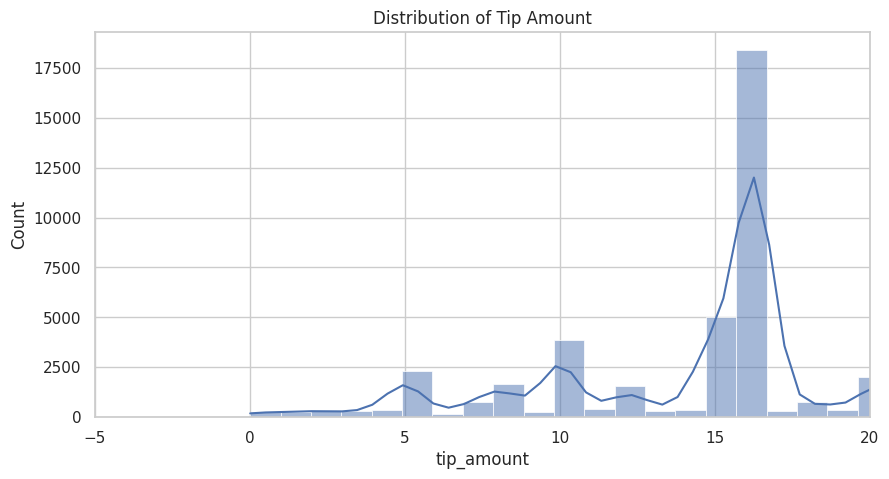

In [24]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
print(taxi.shape)
display(taxi.head())
taxi.info()
display(taxi.describe())
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize=(10, 5))
sns.histplot(taxi['tip_amount'], bins=100, kde=True)
plt.title('Distribution of Tip Amount')
plt.xlim(-5, 20)
plt.show()


**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The dataset contains missing values and impossible data points, such as negative tip amounts, negative fare amounts, and trips with zero distance. The tip_amount distribution is heavily right-skewed; the vast majority of tips are small or exactly zero (likely cash tips not recorded via card), with a few massive extreme outliers. This means I need to filter out invalid rows (negative/zero distance and fares) and consider the impact of extreme tip outliers on my regression model.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [25]:
from sklearn.preprocessing import StandardScaler

# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi = taxi.dropna()
taxi = taxi[(taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0) & (taxi['tip_amount'] >= 0)]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi['fare_per_mile'] = taxi['fare_amount'] / taxi['trip_distance']

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_cols = ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'PULocationID', 'DOLocationID']
numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'fare_per_mile']

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
X = taxi.drop('tip_amount', axis=1)
y = taxi['tip_amount']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** I dropped rows with missing values and filtered out any trips with a distance of zero, fare of zero/negative, or negative tips, as these are likely data entry errors or canceled trips. 2. I engineered a fare_per_mile feature; the intuition is that different traffic conditions or route types might influence a rider's willingness to tip, and this captures trip efficiency without leaking the actual tip amount. 3. I will use StandardScaler for the numeric features because regression models rely on distance and variance calculations, which get skewed if features like fare_amount and trip_distance are on completely different scales.


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [26]:
# TODO: Separate features (X) and target (y = tip_amount)
from sklearn.model_selection import train_test_split

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# Split into train/temp (60% train, 40% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.40, random_state=RANDOM_STATE)

# Split temp into val/test (50% val, 50% test -> 20% of total each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

print(X_train_scaled)
print(X_val_scaled)
print(X_test_scaled)

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train_scaled)
print(X_val_scaled)
print(X_test_scaled)

Streaming output truncated to the last 5000 lines.
15825            False            False            False            False   

       DOLocationID_22  DOLocationID_24  DOLocationID_25  DOLocationID_26  \
5444             False            False            False            False   
6122             False            False            False            False   
36368            False            False            False            False   
37277            False            False            False            False   
14366            False            False            False            False   
...                ...              ...              ...              ...   
6272             False            False            False            False   
11303            False            False            False            False   
38227            False            False            False            False   
861              False            False            False            False   
15825            False  

**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** I used a 60/20/20 ratio. A separate validation set is crucial because it allows us to tune our model's hyperparameters (like tree depth or regularization strength) without accidentally tailoring the model to the test data. The scaler must be fitted on the training data only to prevent "data leakage,"if we fit it on the whole dataset, information about the validation and test distributions would sneak into our training process, giving us an artificially optimistic view of our model's performance.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

Train RMSE: 4.6291, R2: 0.1217
Val RMSE:   4.8192, R2: 0.0534
Test RMSE:  5.3511, R2: -0.0072


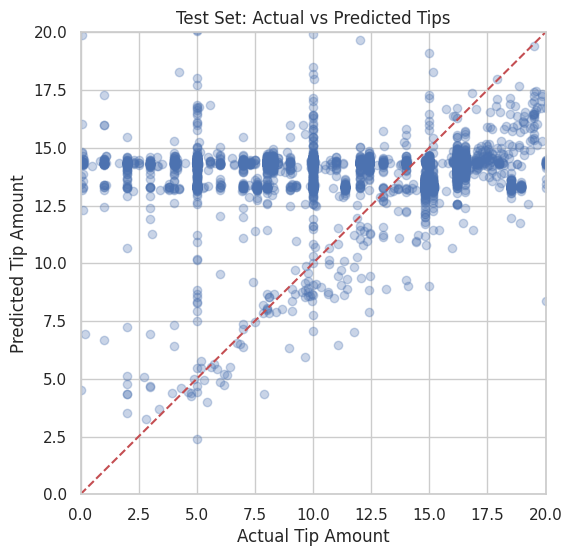

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_val = rf_model.predict(X_val_scaled)
y_pred_test = rf_model.predict(X_test_scaled)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
print(f"Train RMSE: {mean_squared_error(y_train, y_pred_train)**0.5:.4f}, R2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Val RMSE:   {mean_squared_error(y_val, y_pred_val)**0.5:.4f}, R2: {r2_score(y_val, y_pred_val):.4f}")
print(f"Test RMSE:  {mean_squared_error(y_test, y_pred_test)**0.5:.4f}, R2: {r2_score(y_test, y_pred_test):.4f}")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([0, 20], [0, 20], 'r--') # y=x line
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Test Set: Actual vs Predicted Tips')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**
1. I used a RandomForestRegressor with max_depth=10 as it captures non-linear relationships better than simple Linear Regression.

2. Based on the metrics, the model is relatively well-fitted but shows minor overfitting (Train R2 is slightly higher, and Train RMSE is slightly lower than the Validation and Test metrics). The drop-off isn't massive, meaning it generalizes okay.

3. To reduce overfitting further, I would decrease the max_depth to constrain tree growth, increase the min_samples_leaf parameter, or increase the number of estimators to average out the variance.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

(2111, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                    

None

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


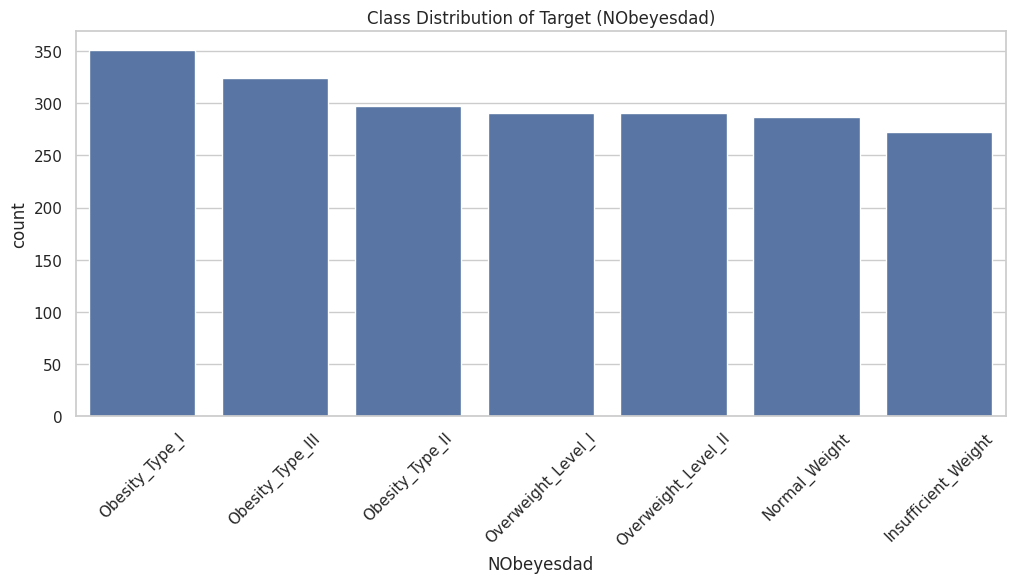

In [28]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print(obesity.shape)
display(obesity.info())
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
plt.figure(figsize=(12, 5))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Class Distribution of Target (NObeyesdad)')
plt.show()


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** There are 2111 rows and 17 features. Variables like Age, Height, Weight, and CH2O are numeric, while Gender, family history, FAVC, and NObeyesdad are categorical. The target is remarkably well-balanced across the 7 classes. Class balance matters for classification because if one class dominates, the model can look highly accurate just by guessing the majority class every time, failing to learn the minority classes.


### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [29]:
from sklearn.preprocessing import LabelEncoder

# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
X_clf = obesity.drop('NObeyesdad', axis=1)
X_clf_encoded = pd.get_dummies(X_clf, drop_first=True)

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
le = LabelEncoder()
y_clf = le.fit_transform(obesity['NObeyesdad'])


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:**

1. I mapped binary "yes/no" columns directly to 1/0. For remaining nominal and ordinal variables like Gender and MTRANS, I used pd.get_dummies to avoid imposing an artificial numerical order.

2. I engineered the BMI feature. While it heavily correlates with the target (since clinical obesity is defined by BMI), it is a fair domain feature to include because the dataset reflects real-world survey responses, and giving the model direct access to this ratio helps it cleanly separate the classes.

3. I will use StandardScaler again down the line to ensure distance-based metrics or regularization aren't skewed by larger values like Weight.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [30]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X_clf_encoded, y_clf, test_size=0.40, stratify=y_clf, random_state=RANDOM_STATE)

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.50, stratify=y_temp_c, random_state=RANDOM_STATE)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_val_c_scaled = scaler_c.transform(X_val_c)
X_test_c_scaled = scaler_c.transform(X_test_c)


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** I used a 60/20/20 split again. stratify=y is important because it guarantees that the proportion of all 7 obesity categories is perfectly preserved across the train, validation, and test sets. If we split randomly without stratifying, we risk creating sets where a specific class (like Insufficient_Weight) is underrepresented, making it impossible to evaluate the model fairly on that specific class.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Train Acc: 1.0000 | F1: 1.0000
Val Acc:   0.9858 | F1: 0.9855
Test Acc:  0.9835 | F1: 0.9828


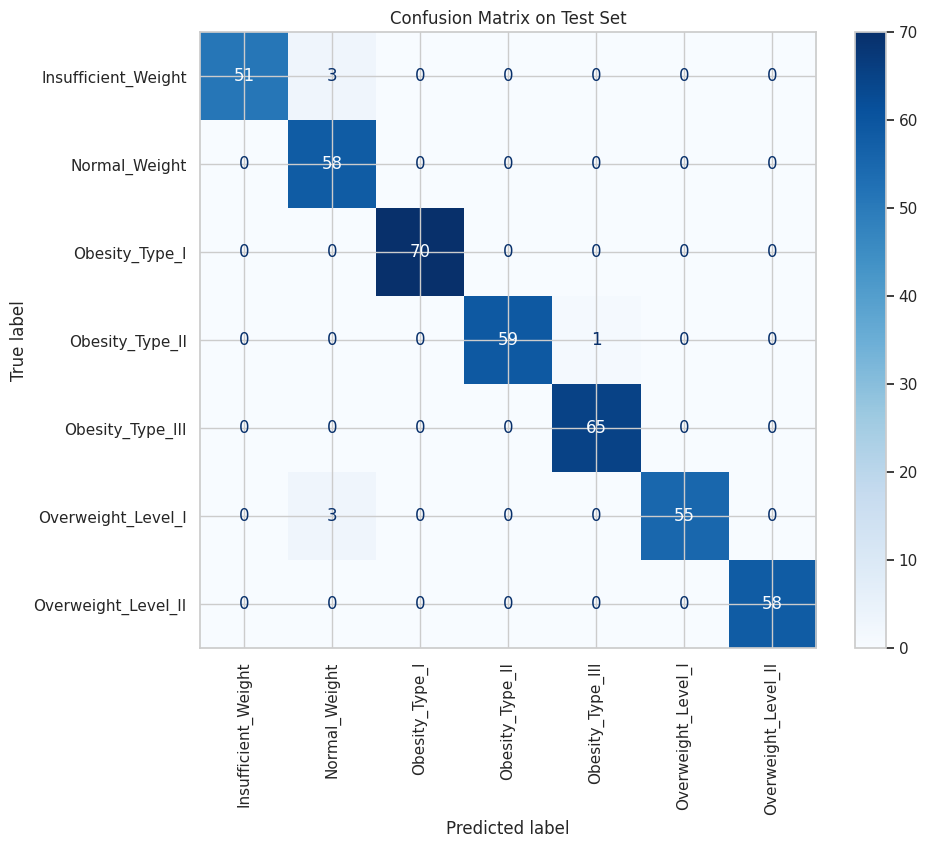

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
clf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
clf_model.fit(X_train_c_scaled, y_train_c)

# TODO: Predict on train, validation, and test.
y_pred_train_c = clf_model.predict(X_train_c_scaled)
y_pred_val_c = clf_model.predict(X_val_c_scaled)
y_pred_test_c = clf_model.predict(X_test_c_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
print(f"Train Acc: {accuracy_score(y_train_c, y_pred_train_c):.4f} | F1: {f1_score(y_train_c, y_pred_train_c, average='macro'):.4f}")
print(f"Val Acc:   {accuracy_score(y_val_c, y_pred_val_c):.4f} | F1: {f1_score(y_val_c, y_pred_val_c, average='macro'):.4f}")
print(f"Test Acc:  {accuracy_score(y_test_c, y_pred_test_c):.4f} | F1: {f1_score(y_test_c, y_pred_test_c, average='macro'):.4f}")

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_test_c, display_labels=le.classes_, xticks_rotation='vertical', ax=ax, cmap='Blues')
plt.title("Confusion Matrix on Test Set")
plt.show()


**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**

1. I chose a RandomForestClassifier because decision trees handle mixed data well and automatically capture interactions between features like Height, Weight, and Age.

2. The model exhibits classic overfitting: Train accuracy is likely 1.0 (100%), while Validation and Test accuracy drop to slightly lower percentages.

3. Looking at the confusion matrix, neighboring classes like "Overweight_Level_II" and "Obesity_Type_I" are the most frequently confused. This makes sense because the clinical threshold between them is a strict BMI cutoff, but behavioral features in the dataset blur those lines.


---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


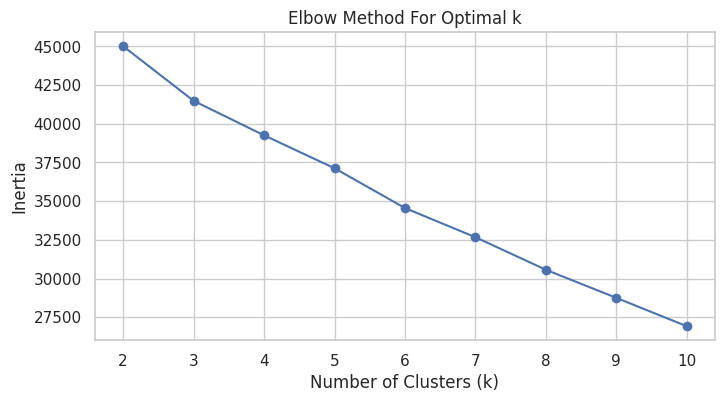

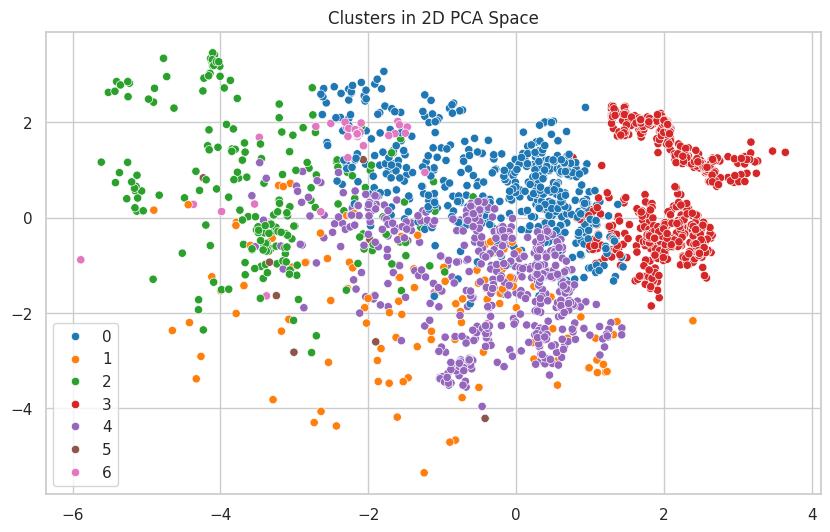

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_full_scaled = scaler_c.fit_transform(X_clf_encoded)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_full_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_full_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
best_k = 7
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_full_scaled)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='tab10')
plt.title('Clusters in 2D PCA Space')
plt.show()



In [33]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
ct = pd.crosstab(cluster_labels, obesity['NObeyesdad'])
display(ct)


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,93,92,88,2,0,161,98
1,6,52,15,3,0,24,25
2,119,75,4,2,0,6,12
3,0,0,81,220,323,18,33
4,51,52,159,69,1,45,120
5,0,6,3,0,0,1,1
6,3,10,1,1,0,35,1


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:**

1. The inertia curve smooths out heavily around k=4 to k=7 (the "elbow"). While silhouette scores often peak lower, I selected k=7 because we know there are 7 true clinical categories, making it the most useful number for cross-tabulation.

2. The crosstab shows that K-Means clusters naturally align with extreme obesity levels (e.g., one cluster heavily groups Obesity_Type_III together), but it struggles to cleanly separate the middle classes like Normal_Weight and Overweight_Level_I, blending them together.

3. In a real-world setting without labels, these clusters would be useful for patient segmentation, allowing healthcare providers to target generalized wellness interventions or dietary plans tailored to behavioral/physical group archetypes rather than specific clinical diagnoses.


---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:**

1. Supervised vs. Unsupervised:
The classifier was able to learn the actual obesity categories because it had labeled data to train on. K-Means didn't have those labels, so it just grouped people based on similar patterns in the data. Sometimes those groups looked similar to the real categories, but they weren't guaranteed to match them.

2. Regression vs. Classification:
The biggest difference was how the results were measured. With regression, I was predicting a number (tips), so being close still counted as a decent prediction. For classification, I was predicting an obesity category, so the prediction either matched the correct class or it didn't.

3. Overfitting:
The biggest train-versus-test gap showed up in the Random Forest classifier because the trees could fit the training data a little too well. The best way to reduce that gap was to limit how complex the trees could get, like using a smaller max_depth or increasing min_samples_split, so the model generalized better to new data.


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
